<a href="https://colab.research.google.com/github/Omkar210/Statistics-and-ML/blob/main/Day28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep
from scipy.stats import chi2
from scipy.stats import f
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from category_encoders import BinaryEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import log_loss
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import Poisson as psn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.api import Holt
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import tensorflow
from tensorflow.keras.models import Sequential  # helps with the forward and backward propagation
from tensorflow.keras.layers import Dense  # this is for the hidden, input and output layers
from tensorflow.keras.layers import ReLU    # activation function
from tensorflow.keras.layers import Dropout   # switching off the neurons
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.cluster import KMeans
import os
print(os.getcwd())
os.chdir('/content/drive/MyDrive/CDAC')
os.getcwd()

/content


'/content/drive/MyDrive/CDAC'

In [5]:
df = pd.read_excel('CDAC_DataBook.xlsx',sheet_name='clusters')

In [10]:
df.head()

,Var1,Var2
0,25,79
1,34,51
2,22,53
3,27,78
4,33,59


In [6]:
ss = StandardScaler()
df_scaled = ss.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled,columns=df.columns,index=df.index)

In [7]:
km = KMeans(n_clusters=3)
mod1 = km.fit(df_scaled)

In [8]:
# 3 Centroids (Standard Scale)
mod1.cluster_centers_

array([[-1.08473514,  1.04670987],
       [ 0.0471624 , -1.17533099],
       [ 1.03757274,  0.12862113]])

In [9]:
# original scale
cc_center = mod1.cluster_centers_
cc_center = pd.DataFrame(cc_center,columns=df.columns)
ss.inverse_transform(cc_center)

array([[29.6, 66.8],
       [43.2, 16.7],
       [55.1, 46.1]])

In [19]:
# Check manually
sd1 = np.std(df.Var1)
mean1 = np.mean(df.Var1)
print(sd , mean1)

sd2 = np.std(df.Var2)
mean2 = np.mean(df.Var2)
print(sd2 , mean2)

print(f'x-axis: {-1.08473514*sd1+mean1}, y-axis: {1.04670987*sd2+mean2}')

12.015221827147244 42.63333333333333
22.546840133375674 43.2
x-axis: 29.60000000253171, y-axis: 66.80000010491644


In [20]:
mydata = pd.DataFrame([[28,72],[40,20],[58,45]], columns=df.columns)
mydata_scaled = ss.transform(mydata)
mod1.predict(mydata_scaled)

array([0, 1, 2], dtype=int32)

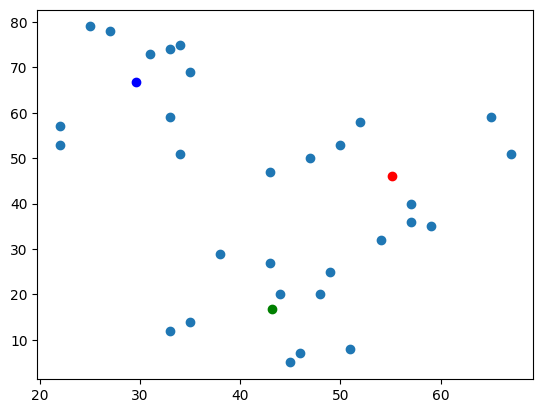

In [25]:
plt.scatter(df['Var1'], df['Var2'])
plt.scatter(43.2,16.7,c='g')
plt.scatter(29.6,66.8,c='b')
plt.scatter(55.1,46.1,c='r')
plt.show()

## Elbow Method to find clusters

In [26]:
# within cluster variation
mod1.inertia_

12.510203077852196

In [31]:
# checking within cluster variation
wcv = []
for i in range(2,16):
    km = KMeans(n_clusters=i)
    mod1 = km.fit(df_scaled)
    wcv.append(mod1.inertia_)

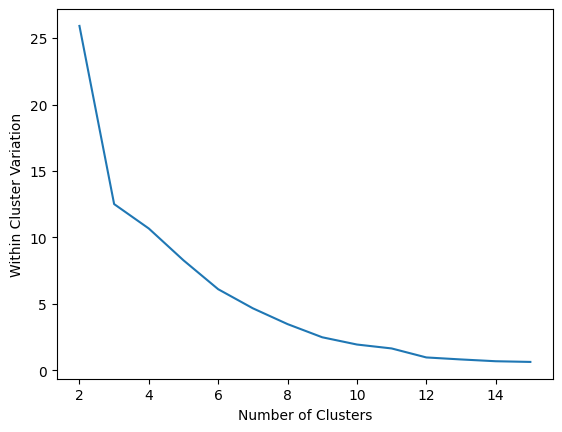

In [33]:
plt.plot(list(range(2,16)),wcv)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Variation')
plt.show()